In [ ]:
import tkinter as tk
from tkinter import scrolledtext, messagebox
import requests
from bs4 import BeautifulSoup

   class SearchApp:
       def __init__(self, root):
           self.root = root
           self.root.title("News and Wiki Search")
           self.root.geometry("600x500")

           # Label for search query
           tk.Label(root, text="Enter Search Query:", font=("Arial", 12)).pack(pady=10)

           # Entry for search query
           self.query_entry = tk.Entry(root, width=50, font=("Arial", 10))
           self.query_entry.pack(pady=5)

           # Buttons for search
           tk.Button(root, text="Search Wikinews", command=self.search_wikinews, font=("Arial", 10)).pack(pady=5)
           tk.Button(root, text="Search Wikipedia", command=self.search_wikipedia, font=("Arial", 10)).pack(pady=5)

           # Scrolled text area for results
           self.result_text = scrolledtext.ScrolledText(root, width=70, height=20, font=("Arial", 10))
           self.result_text.pack(pady=10)

       def search_wikinews(self):
           query = self.query_entry.get().strip()
           if not query:
               messagebox.showwarning("Input Error", "Please enter a search query.")
               return

           self.result_text.delete(1.0, tk.END)  # Clear previous results
           self.result_text.insert(tk.END, f"Searching Wikinews for '{query}'...\n\n")

           try:
               search_url = f"https://en.wikinews.org/w/index.php?search={query}&title=Special%3ASearch&profile=default&fulltext=1"
               response = requests.get(search_url, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)

               if response.status_code == 200:
                   soup = BeautifulSoup(response.text, "html.parser")
                   news = soup.select("div.mw-search-result-heading a")

                   if news:
                       self.result_text.insert(tk.END, f"Wikinews Search Results for '{query}':\n")
                       for item in news:
                           title = item.text
                           link = "https://en.wikinews.org" + item["href"]
                           self.result_text.insert(tk.END, f"- {title}: {link}\n")
                   else:
                       self.result_text.insert(tk.END, f"No news articles found for '{query}'.\n")
               else:
                   self.result_text.insert(tk.END, f"Failed to fetch the page (Status Code: {response.status_code}).\n")
           except requests.RequestException as e:
               self.result_text.insert(tk.END, f"Error during Wikinews search: {str(e)}\n")

       def search_wikipedia(self):
           query = self.query_entry.get().strip()
           if not query:
               messagebox.showwarning("Input Error", "Please enter a search query.")
               return

           self.result_text.delete(1.0, tk.END)  # Clear previous results
           self.result_text.insert(tk.END, f"Searching Wikipedia for '{query}'...\n\n")

           try:
               url = f"https://en.wikipedia.org/w/api.php?action=query&format=json&list=search&srsearch={query}&srlimit=50"
               response = requests.get(url, timeout=10)
               response.raise_for_status()  # Raise an exception for bad status codes
               data = response.json()

               results = data["query"]["search"]
               if results:
                   self.result_text.insert(tk.END, "Wikipedia Results:\n")
                   for item in results:
                       title = item["title"]
                       snippet = item["snippet"].replace("<span class=\"searchmatch\">", "").replace("</span>", "")
                       self.result_text.insert(tk.END, f"{title} - {snippet}\n")
               else:
                   self.result_text.insert(tk.END, f"No Wikipedia articles found for '{query}'.\n")
           except requests.RequestException as e:
               self.result_text.insert(tk.END, f"Error during Wikipedia search: {str(e)}\n")

   if __name__ == "__main__":
       root = tk.Tk()
       app = SearchApp(root)
       root.mainloop()

IndentationError: unexpected indent (3598842751.py, line 2)

Relationships Data:
   Product_A      Product_B  Frequency
0  iPhone 12      iPhone 13        100
1  iPhone 12      iPhone 14        200
2  iPhone 12      iPhone 15        300
3  iPhone 13      iPhone 14        100
4  iPhone 13      iPhone 15        200
5  iPhone 14      iPhone 15        100
6  iPhone 14  iPhone 15 Pro        300
7  iPhone 15  iPhone 15 Pro        200


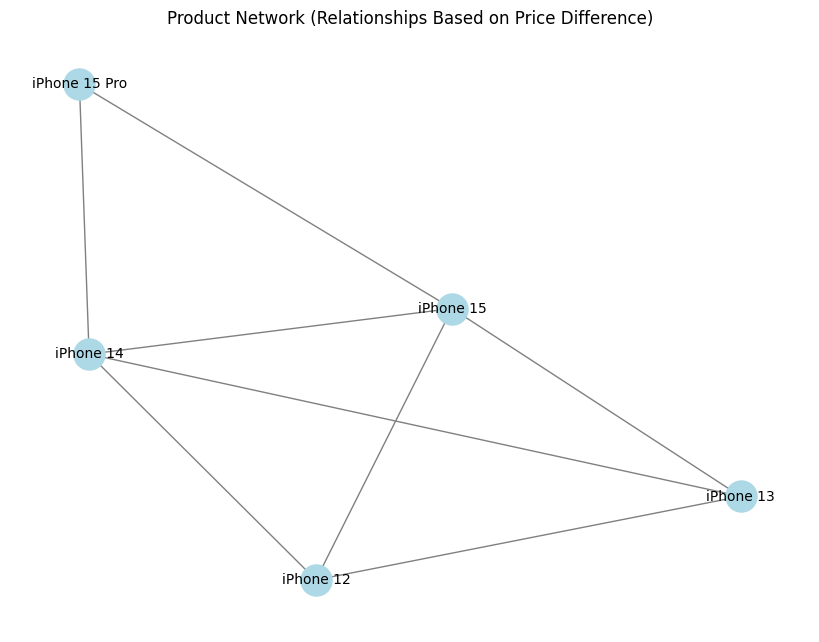

Importance of Products (Popularity): {'iPhone 12': 0.75, 'iPhone 13': 0.75, 'iPhone 14': 1.0, 'iPhone 15': 1.0, 'iPhone 15 Pro': 0.5}
Communities: {'iPhone 12': 0, 'iPhone 13': 0, 'iPhone 14': 1, 'iPhone 15': 0, 'iPhone 15 Pro': 1}


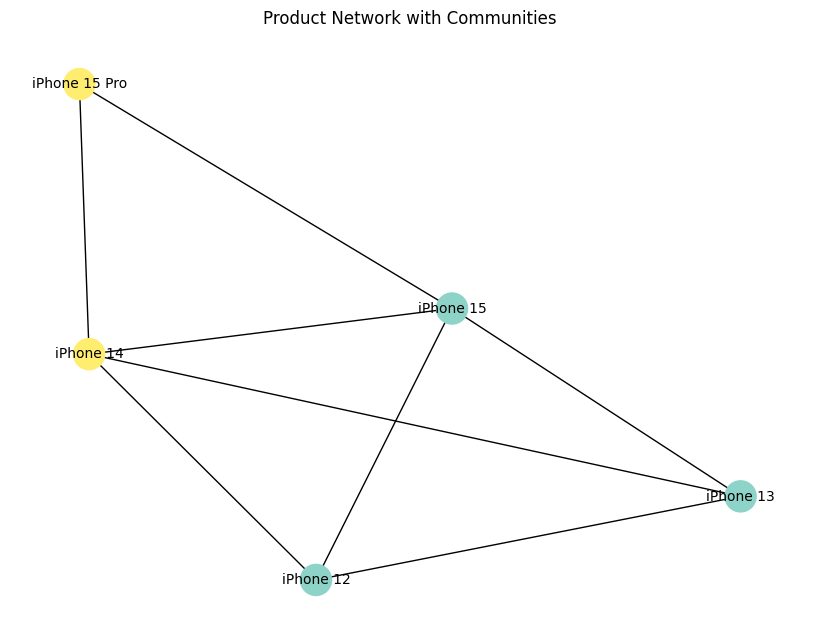

In [14]:
#Network Analysis with NetworkX:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from community import community_louvain


relationships_df = pd.read_csv("relationships_data.csv")
print("Relationships Data:")
print(relationships_df)


G = nx.Graph()
for _, row in relationships_df.iterrows():
    G.add_edge(row["Product_A"], row["Product_B"], weight=row["Frequency"])


plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=10, edge_color='gray')
plt.title("Product Network (Relationships Based on Price Difference)")
plt.show()


degree_centrality = nx.degree_centrality(G)
print("Importance of Products (Popularity):", degree_centrality)


partition = community_louvain.best_partition(G)
print("Communities:", partition)


plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color=list(partition.values()), cmap=plt.cm.Set3, node_size=500, font_size=10)
plt.title("Product Network with Communities")
plt.show()

Main Data:
          Product  Price         Region  \
0       iPhone 12    699  North America   
1       iPhone 12    720         Europe   
2       iPhone 12    710           Asia   
3       iPhone 13    799  North America   
4       iPhone 13    820         Europe   
5       iPhone 13    810           Asia   
6       iPhone 14    899  North America   
7       iPhone 14    920         Europe   
8       iPhone 14    910           Asia   
9       iPhone 15    999  North America   
10      iPhone 15   1020         Europe   
11      iPhone 15   1010           Asia   
12  iPhone 15 Pro   1199  North America   
13  iPhone 15 Pro   1220         Europe   
14  iPhone 15 Pro   1210           Asia   

                                          Description  \
0   The iPhone 12 and iPhone 12 Mini (stylized and...   
1   The iPhone 12 and iPhone 12 Mini (stylized and...   
2   The iPhone 12 and iPhone 12 Mini (stylized and...   
3   The iPhone 13 and iPhone 13 Mini (stylized as ...   
4   The iPhone 

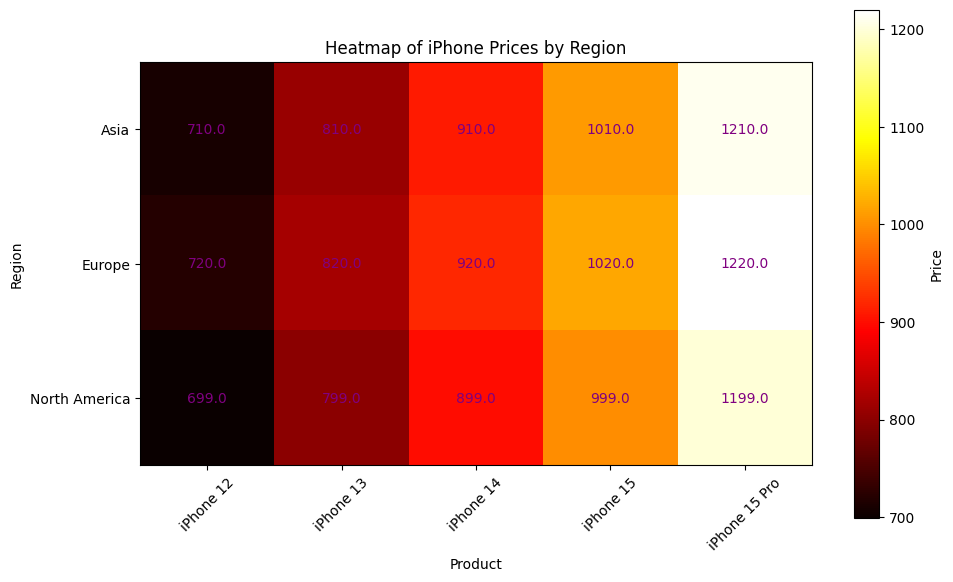

In [15]:
#Load the main data from products_data.csv and  Create the Heatmap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("products_data.csv")
print("Main Data:")
print(df)


pivot_table = df.pivot_table(index="Region", columns="Product", values="Price", aggfunc="mean") #aggfunc="mean"  لو حاجتين لهم نفس السعر بتجيب متوسط السعر بتاعهم
print("Pivot Table for Heatmap:")
print(pivot_table)


plt.figure(figsize=(10, 6))
heatmap_data = pivot_table.values
im = plt.imshow(heatmap_data, cmap="hot", interpolation="nearest") # interpolation="nearest"  مش بتخلط الالوان بتخليها مربعات واضحة
plt.colorbar(im, label="Price")
plt.xticks(np.arange(len(pivot_table.columns)), pivot_table.columns, rotation=45)
plt.yticks(np.arange(len(pivot_table.index)), pivot_table.index)
for i in range(len(pivot_table.index)):
    for j in range(len(pivot_table.columns)):
        plt.text(j, i, f"{heatmap_data[i, j]:.1f}", ha="center", va="center", color="purple")
plt.title("Heatmap of iPhone Prices by Region")
plt.xlabel("Product")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

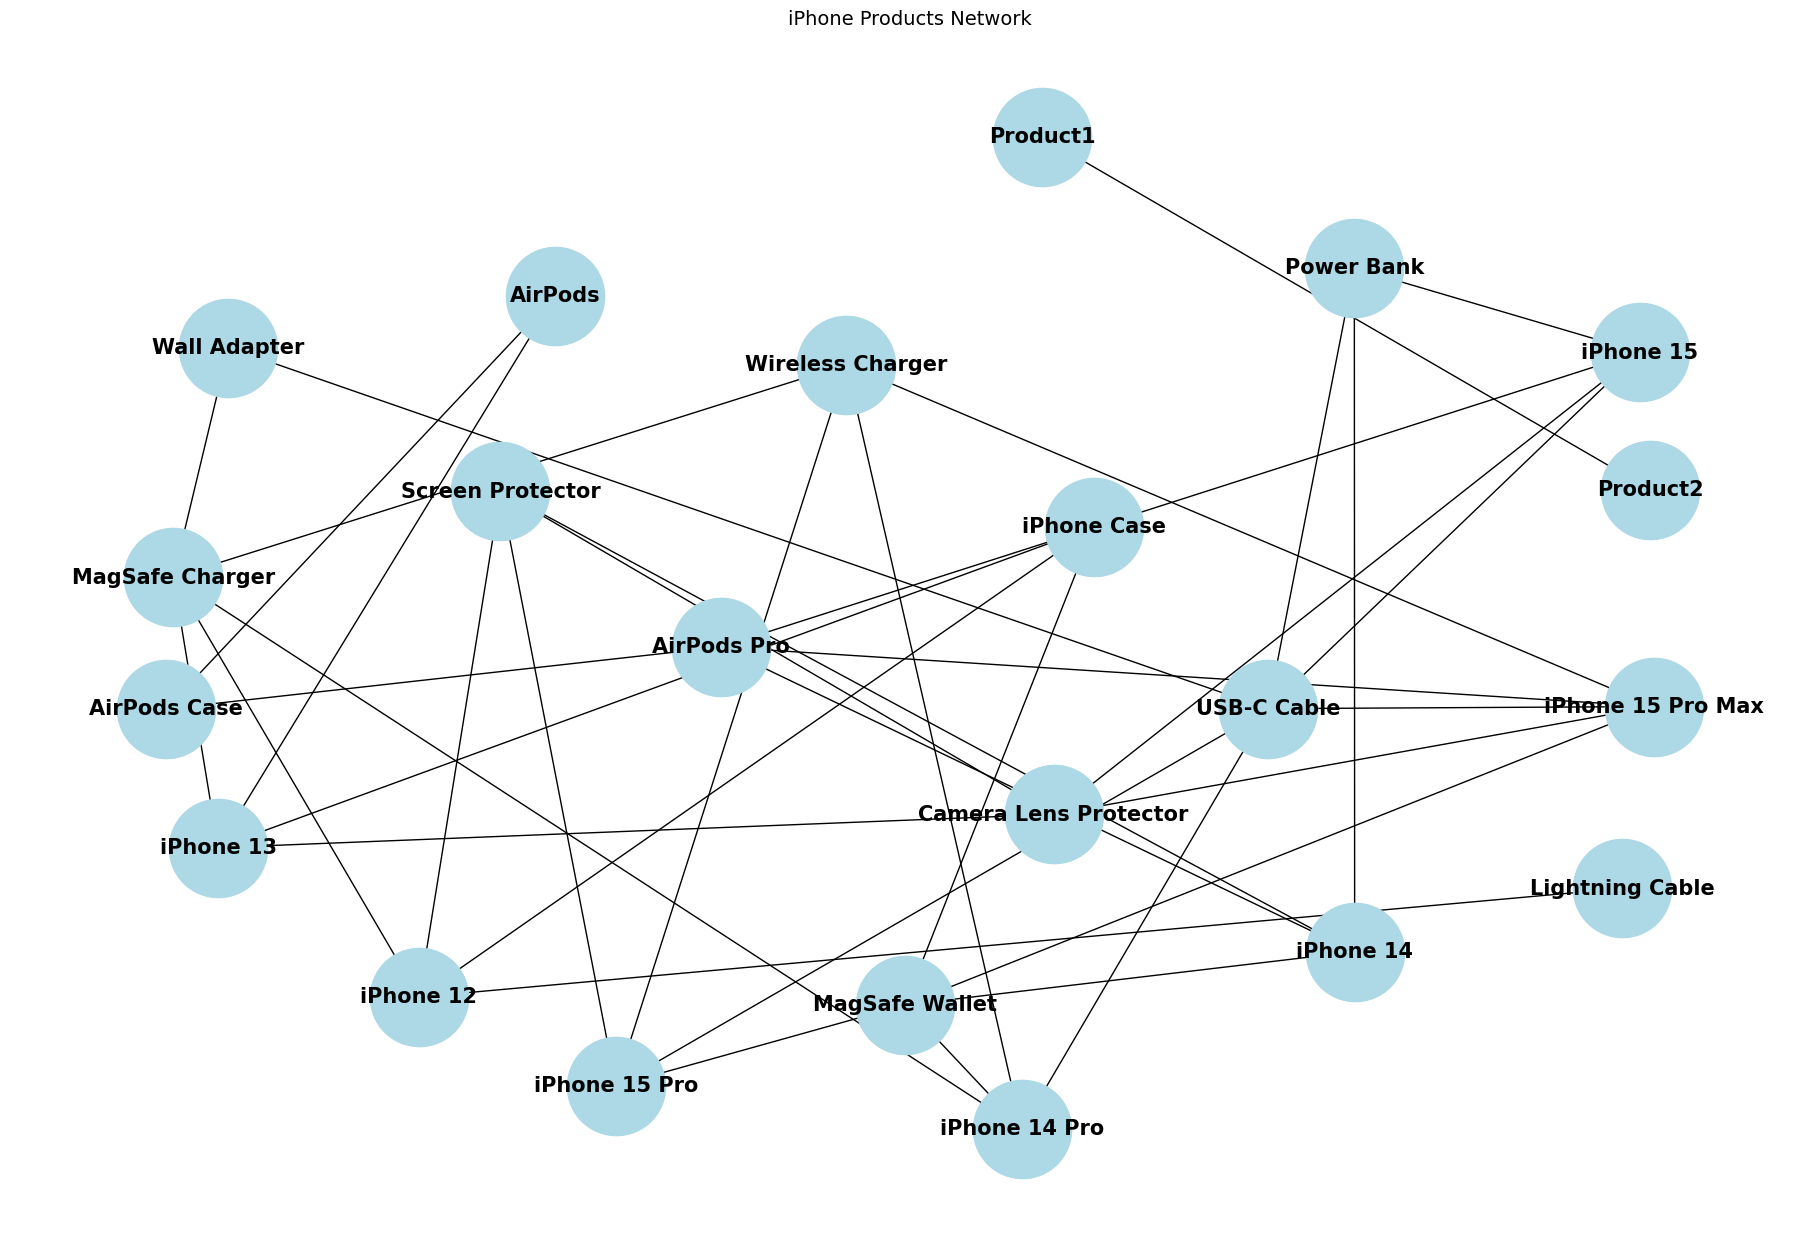

Most connected product for each iPhone model:

iPhone 12 ➜ MagSafe Charger (connections: 5)
iPhone Case ➜ MagSafe Wallet (connections: 5)
iPhone 13 ➜ MagSafe Charger (connections: 5)
iPhone 14 ➜ MagSafe Wallet (connections: 5)
iPhone 14 Pro ➜ USB-C Cable (connections: 6)
iPhone 15 ➜ USB-C Cable (connections: 6)
iPhone 15 Pro ➜ USB-C Cable (connections: 6)
iPhone 15 Pro Max ➜ USB-C Cable (connections: 6)


In [12]:
# -*- coding: utf-8 -*-
"""phase 3.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1Upm5muk00BqyyxqO_Wd2Xr5YA78uAGvu
"""

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('modern_iphone_relations.csv', header=None, names=['Product1', 'Product2'])


G = nx.Graph()
G.add_edges_from(df.values)

plt.figure(figsize=(18, 12))
pos = nx.spring_layout(G, seed=42,k = 2, scale = 3)
nx.draw(G, pos, with_labels=True, node_size=5000, node_color='lightblue', font_size=15,font_weight ='bold')
plt.title("iPhone Products Network", fontsize=14)
plt.show()


iphone_models = [node for node in G.nodes if "iPhone" in node]

print("Most connected product for each iPhone model:\n")
for model in iphone_models:
    neighbors = list(G.neighbors(model))
    if not neighbors:
        print(f"{model}: No related products.")
        continue

    most_related = sorted(neighbors, key=lambda x: G.degree(x), reverse=True)[0]
    print(f"{model} ➜ {most_related} (connections: {G.degree(most_related)})")



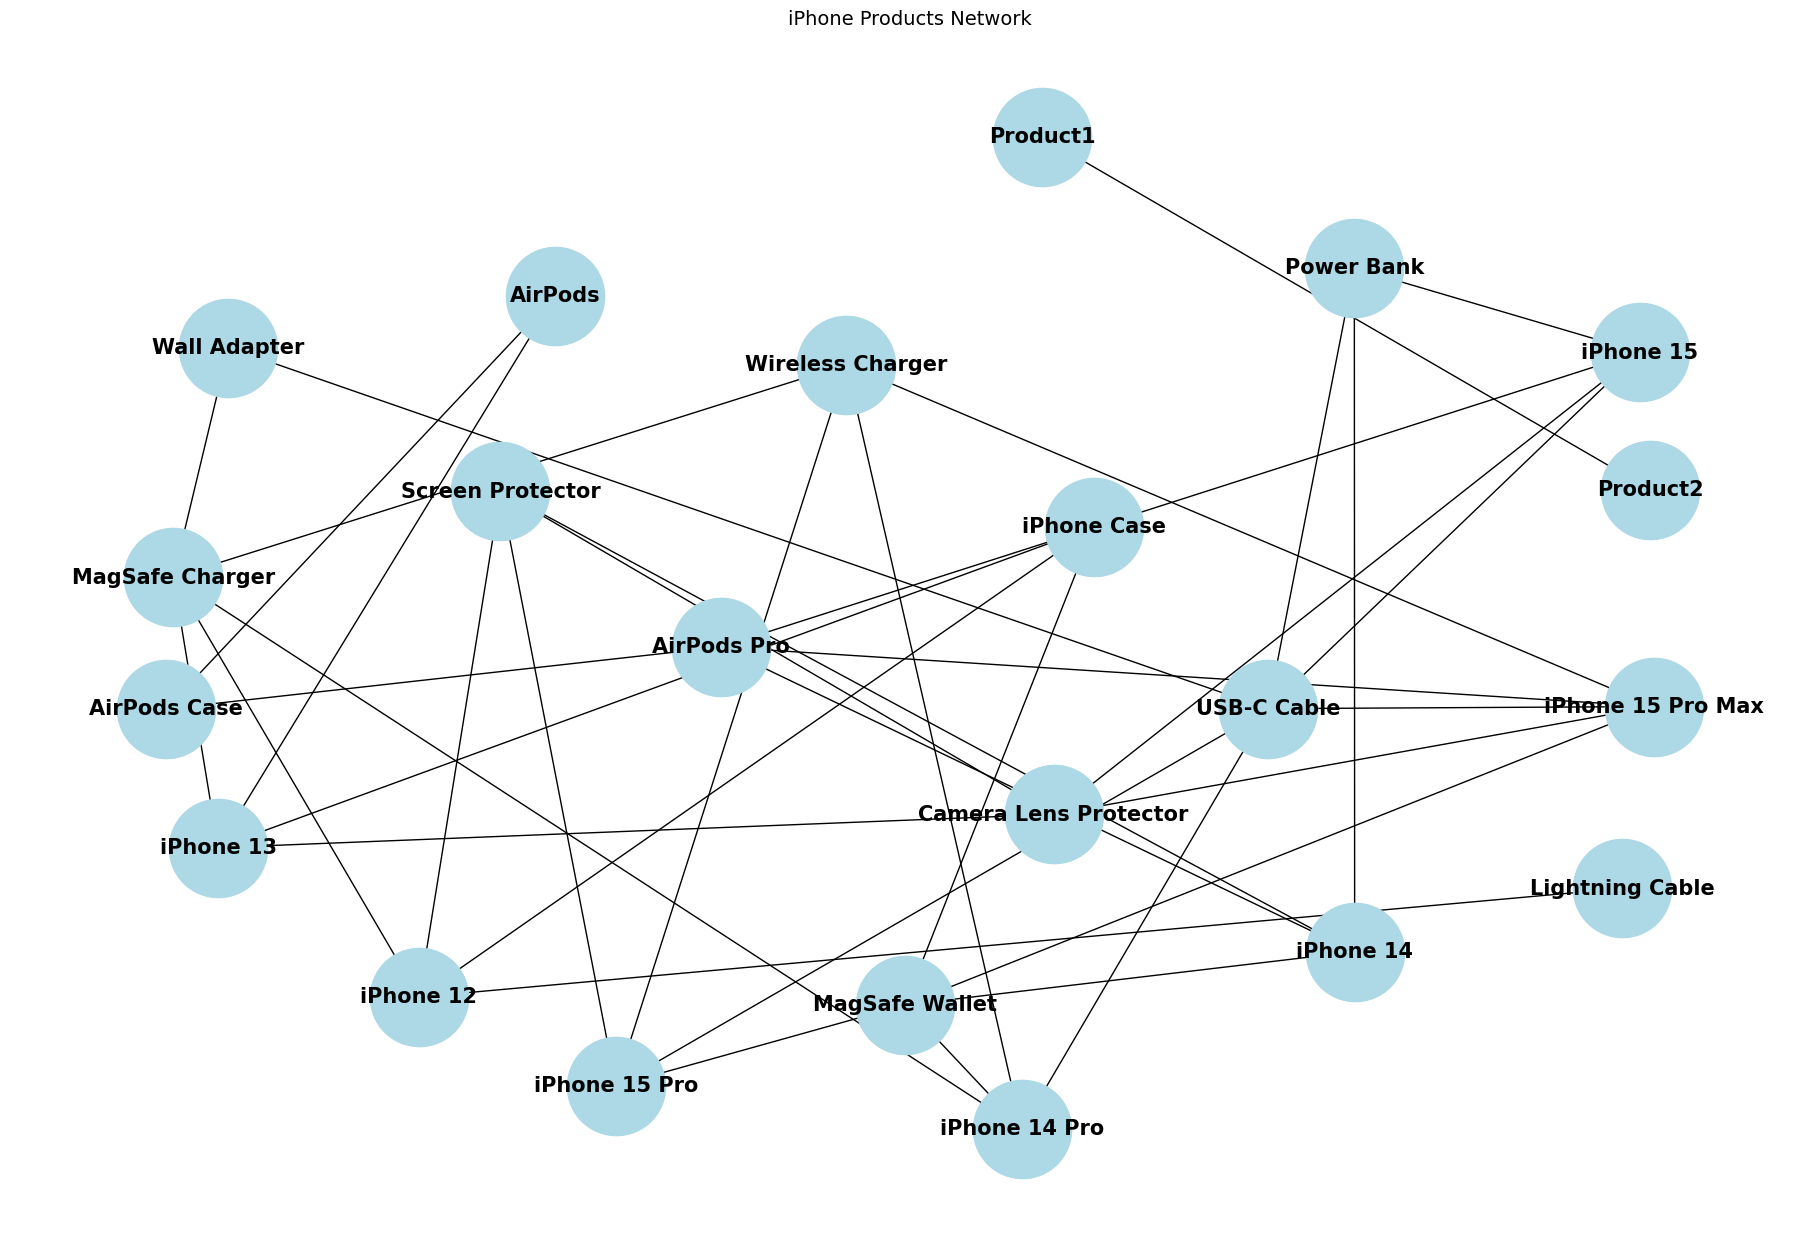

Most connected product for each iPhone model:

iPhone 12 ➜ MagSafe Charger (connections: 5)
iPhone Case ➜ MagSafe Wallet (connections: 5)
iPhone 13 ➜ MagSafe Charger (connections: 5)
iPhone 14 ➜ MagSafe Wallet (connections: 5)
iPhone 14 Pro ➜ USB-C Cable (connections: 6)
iPhone 15 ➜ USB-C Cable (connections: 6)
iPhone 15 Pro ➜ USB-C Cable (connections: 6)
iPhone 15 Pro Max ➜ USB-C Cable (connections: 6)


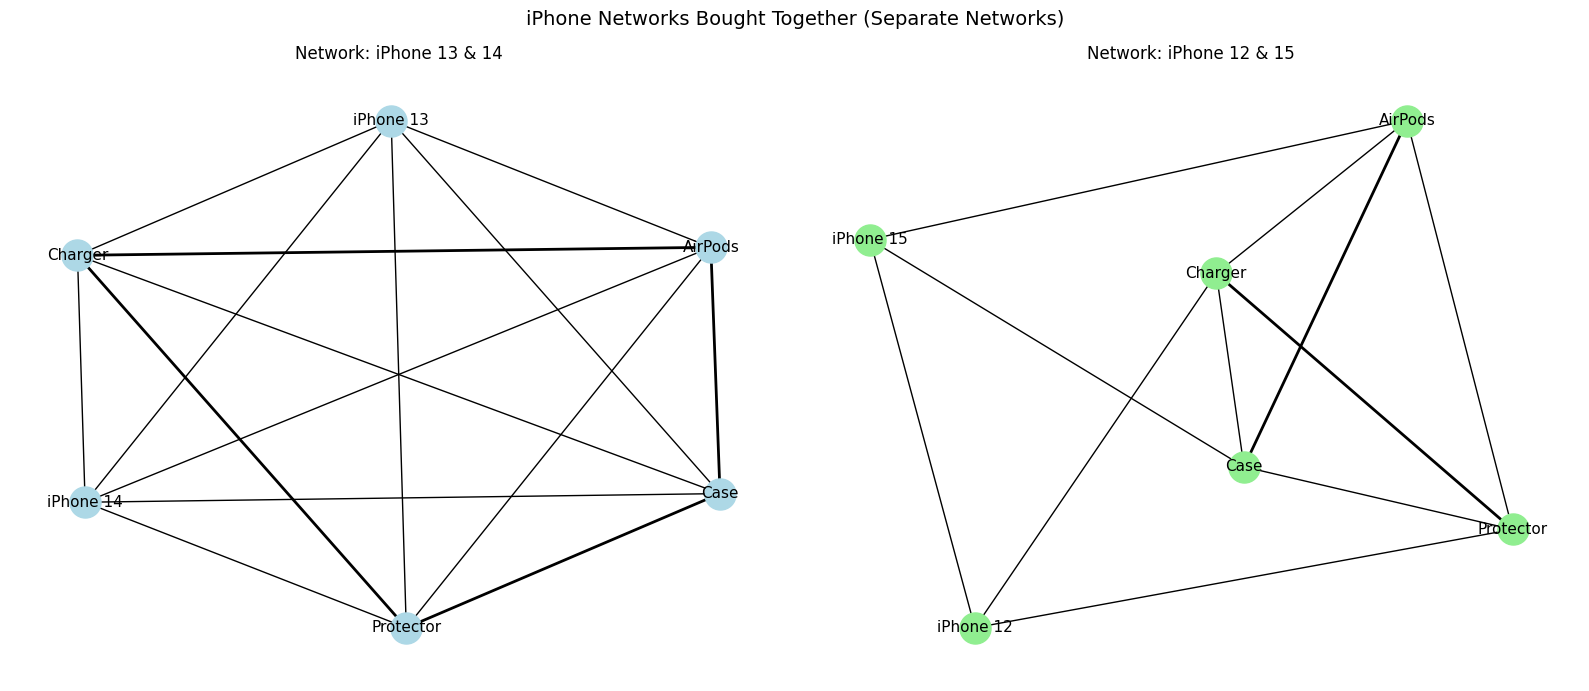

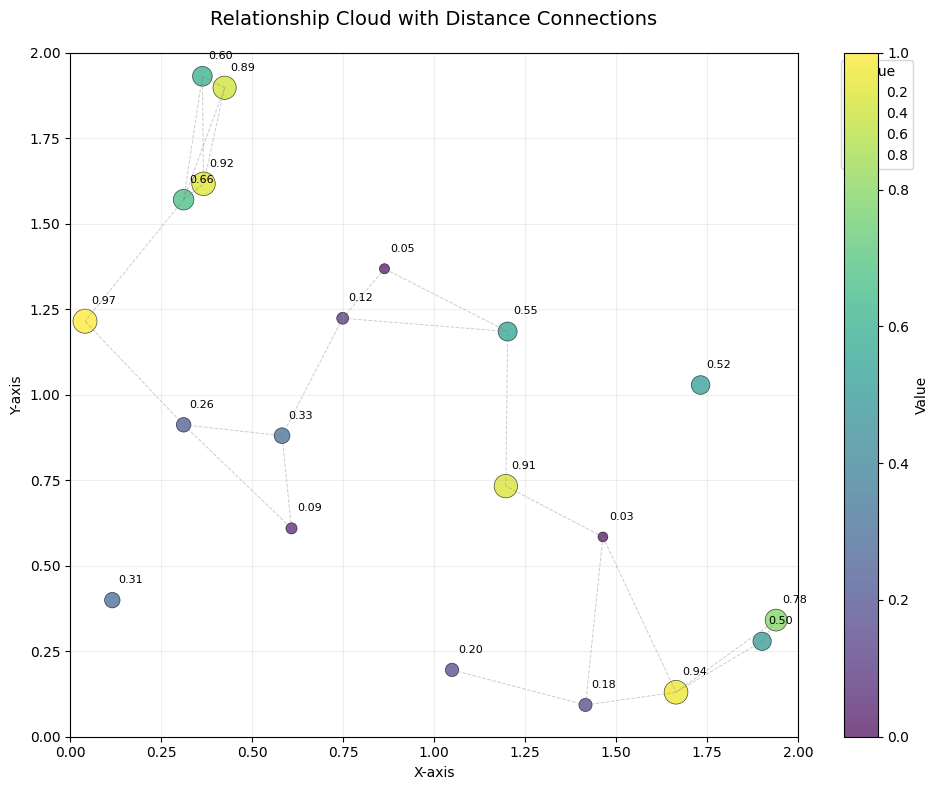

In [13]:
# -*- coding: utf-8 -*-
"""phase 222.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1Upm5muk00BqyyxqO_Wd2Xr5YA78uAGvu
"""

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('modern_iphone_relations.csv', header=None, names=['Product1', 'Product2'])


G = nx.Graph()
G.add_edges_from(df.values)

plt.figure(figsize=(18, 12))
pos = nx.spring_layout(G, seed=42,k = 2, scale = 3)
nx.draw(G, pos, with_labels=True, node_size=5000, node_color='lightblue', font_size=15,font_weight ='bold')
plt.title("iPhone Products Network", fontsize=14)
plt.show()


iphone_models = [node for node in G.nodes if "iPhone" in node]

print("Most connected product for each iPhone model:\n")
for model in iphone_models:
    neighbors = list(G.neighbors(model))
    if not neighbors:
        print(f"{model}: No related products.")
        continue

    most_related = sorted(neighbors, key=lambda x: G.degree(x), reverse=True)[0]
    print(f"{model} ➜ {most_related} (connections: {G.degree(most_related)})")

import networkx as nx
import matplotlib.pyplot as plt

graph1 = nx.Graph()


shared_labels = {
    3: "Case",
    4: "Protector",
    5: "AirPods",
    6: "Charger"
}


orders1 = [
    [1, 3, 4],
    [2, 3, 5],
    [1, 5, 6],
    [2, 4, 6],
    [1, 2],
    [3, 4, 5, 6]
]


for order in orders1:
    for i in range(len(order)):
        for j in range(i+1, len(order)):
            a, b = order[i], order[j]
            if graph1.has_edge(a, b):
                graph1[a][b]['count'] += 1
            else:
                graph1.add_edge(a, b, count=1)

labels1 = {
    1: "iPhone 13",
    2: "iPhone 14",
    **shared_labels
}


graph2 = nx.Graph()


orders2 = [
    [7, 3, 5],
    [8, 4, 6],
    [7, 8],
    [3, 4, 5, 6]
]


for order in orders2:
    for i in range(len(order)):
        for j in range(i+1, len(order)):
            a, b = order[i], order[j]
            if graph2.has_edge(a, b):
                graph2[a][b]['count'] += 1
            else:
                graph2.add_edge(a, b, count=1)

labels2 = {
    7: "iPhone 15",
    8: "iPhone 12",
    **shared_labels
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))


pos1 = nx.spring_layout(graph1, seed=42)
nx.draw(graph1, pos1, ax=axes[0], with_labels=False, node_size=500, node_color='lightblue', width=[graph1[u][v]['count'] for u, v in graph1.edges()])
nx.draw_networkx_labels(graph1, pos1, labels=labels1, ax=axes[0], font_size=11)
axes[0].set_title("Network: iPhone 13 & 14")
axes[0].axis('off')


pos2 = nx.spring_layout(graph2, seed=99)
nx.draw(graph2, pos2, ax=axes[1], with_labels=False, node_size=500, node_color='lightgreen', width=[graph2[u][v]['count'] for u, v in graph2.edges()])
nx.draw_networkx_labels(graph2, pos2, labels=labels2, ax=axes[1], font_size=11)
axes[1].set_title("Network: iPhone 12 & 15")
axes[1].axis('off')

plt.suptitle("iPhone Networks Bought Together (Separate Networks)", fontsize=14)
plt.tight_layout()
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# إنشاء بيانات عشوائية مشابهة للصورة
np.random.seed(42)
n_points = 20
x = np.random.uniform(0, 2, n_points)
y = np.random.uniform(0, 2, n_points)
values = np.random.uniform(0, 1, n_points)

# إنشاء DataFrame
df = pd.DataFrame({'X': x, 'Y': y, 'Value': values})

# إنشاء الشكل
plt.figure(figsize=(10, 8))

# رسم سحابة النقاط
scatter = sns.scatterplot(
    data=df,
    x='X',
    y='Y',
    size='Value',
    hue='Value',
    sizes=(50, 300),  # نطاق أحجام النقاط
    palette='viridis',
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

# إضافة تسميات للنقاط
for i in range(len(df)):
    plt.text(
        x=df.X[i]+0.05,
        y=df.Y[i]+0.05,
        s=f"{df.Value[i]:.2f}",
        fontsize=8,
        ha='center'
    )

# إضافة خطوط للعلاقات بين النقاط القريبة
threshold = 0.5  # عتبة المسافة لعرض الخطوط
for i in range(len(df)):
    for j in range(i+1, len(df)):
        distance = np.sqrt((df.X[i]-df.X[j])**2 + (df.Y[i]-df.Y[j])**2)
        if distance < threshold:
            plt.plot(
                [df.X[i], df.X[j]],
                [df.Y[i], df.Y[j]],
                color='gray',
                linestyle='--',
                alpha=0.4,
                linewidth=0.7
            )

# تحسين العناوين والتنسيق
plt.title('Relationship Cloud with Distance Connections', pad=20, fontsize=14)
plt.xlabel('X-axis', fontsize=10)
plt.ylabel('Y-axis', fontsize=10)
plt.grid(True, alpha=0.2)
plt.xlim(0, 2)
plt.ylim(0, 2)

# إضافة شريط الألوان
plt.colorbar(scatter.collections[0], label='Value')
plt.legend(title='Value', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()